[目录](./table_of_contents.ipynb)


# 前言


In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

卡尔曼滤波（Kalman filter）与贝叶斯滤波（Bayesian filter）入门教材。本书使用 Jupyter Notebook 编写，你可以在浏览器中阅读，也可以运行并修改代码，在书中直接看到结果。还有什么比这更好的学习方式呢？


## 卡尔曼滤波与贝叶斯滤波

传感器是有噪声的。世界上充满着我们想要测量和跟踪的数据与事件，但我们不能指望传感器给出完美信息。我车上的 GPS 会报告海拔高度，每次经过同一段路，它报告的高度都略有不同。厨房秤对同一物体称两次，读数也不完全一样。

在简单情况下，解决办法显而易见。如果秤的读数略有波动，我可以多称几次取平均；或者换一台更精确的秤。但当传感器噪声很大，或环境使数据采集变得困难时，我们该怎么办？我们也许要跟踪一架低空飞行的飞机，要为无人机编写自动驾驶程序，或要确保农场拖拉机播遍了整块田地。我从事计算机视觉工作，需要在图像中跟踪运动物体，而计算机视觉算法往往给出非常嘈杂、不可靠的结果。

本书教你如何解决这类滤波（filtering）问题。我会用到许多不同算法，但它们都基于*贝叶斯概率（Bayesian probability）*。简单地说，贝叶斯概率根据既往信息判断什么更可能是真的。

若此刻问你我的车头朝向，你毫无头绪，只能在 1$^\circ$ 到 360$^\circ$ 之间猜一个数，猜对的概率约为 1/360。但若我告诉你 2 秒前朝向是 243$^\circ$，在 2 秒内车不可能转太大，你就能做出准确得多的预测。你正在用过去的信息，更准确地推断现在或未来的情况。

世界同样充满噪声。上述预测能帮你得到更好的估计，但它也会受噪声影响：我可能刚为避让狗而刹车，或绕开坑洼；强风、路面结冰等外部因素都会影响行车轨迹。在控制理论文献中，我们称之为*噪声（noise）*，尽管你可能并不习惯这样称呼。

贝叶斯概率还有更多内容，但核心思想你已经掌握：知识是不确定的，我们会根据证据强弱调整信念。卡尔曼滤波与贝叶斯滤波将我们对系统行为嘈杂而有限的知识，与嘈杂而有限的传感器读数相融合，得到对系统状态的尽可能好的估计。我们的原则是永不丢弃信息。

假设我们在跟踪一个物体，传感器报告它突然改变了方向。它是真转了，还是数据噪声？视情况而定。若是战斗机，我们很可能相信突然机动的报告；若是直线轨道上的货运列车，则会打折扣。我们还会根据传感器精度进一步修正判断。信念取决于历史、对所跟踪系统的认识，以及传感器特性。

卡尔曼滤波（Kalman filter）由 Rudolf Emil Kálmán 发明，以数学上最优的方式解决这类问题。它首次用于阿波罗登月任务，此后应用于极其广泛的领域：飞机、潜艇、巡航导弹上都有卡尔曼滤波；华尔街用它跟踪市场；机器人、物联网（IoT）传感器、实验室仪器中都有应用；化工厂用它控制与监测反应；医学成像、心电信号去噪也离不开它。只要涉及传感器和/或时间序列数据，通常就会用到卡尔曼滤波或其近亲。


## 写作本书的动机

我是一名软件工程师，在航空航天领域工作了近二十年，一直与卡尔曼滤波（Kalman filter）“擦肩而过”，却从未亲手实现过。它向来以难学著称：理论很美，但若未受过信号处理、控制理论、概率与统计、制导与控制理论等训练，学起来相当吃力。当我转向用计算机视觉解决跟踪问题时，自己实现滤波器的需求变得迫切。

该领域有优秀教材，例如 Grewal 与 Andrew 的 *Kalman Filtering*。但若缺乏必要背景，坐下来读这类书往往是沮丧而艰难的经历。通常前几章会在几页内扫过数年本科数学，轻描淡写地让你去读伊藤演算（Itō calculus）教材，又用寥寥几段讲完一整学期的统计内容。它们是本科高年级或研究生课程教材，对研究者与专业人士是无价参考，但对更随意的读者来说实在艰涩。符号不经解释就登场，不同文献对同一概念用不同词语与变量名，书中几乎缺少例题与习题。我常能读懂定义的字面意思、理解其中的数学，却完全不知道这些文字与公式在描述什么现实现象。“但这到底*是什么意思*？”是我反复自问的话。下面是我曾经困惑的典型例子：

$$\begin{aligned}\hat{x}_{k} = \Phi_{k}\hat{x}_{k-1} + G_k u_{k-1} + K_k [z_k - H \Phi_{k} \hat{x}_{k-1} - H G_k u_{k-1}]
\\ 
\mathbf{P}_{k\mid k} = (I - \mathbf{K}_k \mathbf{H}_{k})\textrm{cov}(\mathbf{x}_k - \hat{\mathbf{x}}_{k\mid k-1})(I - \mathbf{K}_k \mathbf{H}_{k})^{\text{T}}  + \mathbf{K}_k\textrm{cov}(\mathbf{v}_k )\mathbf{K}_k^{\text{T}}\end{aligned}$$

然而，当我终于理解卡尔曼滤波时，发现底层概念相当直白。若掌握几条简单概率规则，并对如何融合不确定知识有直觉，卡尔曼滤波的概念并不难触及。卡尔曼滤波虽以难学闻名，但剥去大量形式化术语后，这一主题及其数学之美对我变得清晰，我也爱上了它。

随着对数学与理论理解加深，新的困难又出现了：书或论文陈述某事实并给出图作为证明，却不清楚为何成立，或我无法复现该图；或我会想“若 R=0 是否仍成立？”；或作者给出的伪代码层次太高，实现并不显然。有些书提供 Matlab 代码，但我没有那个昂贵软件的许可证。最后，许多书每章末尾有大量有用习题——若想自己实现卡尔曼滤波就必须弄懂——却没有答案。课堂用书或许尚可，对自学者则很糟糕。我讨厌作者对我隐瞒信息，大概是为了防止学生“作弊”。

这一切阻碍学习。我想在屏幕上跟踪图像，或为 Arduino 项目写代码；想知道书中的图如何生成，并选用与作者不同的参数；想跑仿真，往信号里加更多噪声看滤波器表现。日常代码中有成千上万处可用卡尔曼滤波，却似乎成了火箭科学家与学者的专属领域。

我写本书就是为了回应这些需求。若你设计军用雷达，本书并非唯一读物——去顶尖理工院校读硕士或博士吧，你会需要那些训练。本书面向爱好者、好奇者，以及需要滤波或平滑（smoothing）数据的在职工程师。若是爱好者，本书应能提供你所需的一切；若要认真钻研卡尔曼滤波，你还需要更多。我的意图是介绍足够多的概念与数学，使教材与论文变得可读。

本书是交互式的。你可以像静态内容一样在线阅读，但我建议你按设计方式使用。它用 Jupyter Notebook 编写，使我能在同一处结合文字、数学、Python 与 Python 输出。书中每一张图、每一条数据都在 notebook 内由 Python 生成。想把某参数加倍？改参数值，按 CTRL-ENTER，新的图或打印输出就会出现。

本书有习题，也有答案。我信任你。若只需答案，直接看即可；若想内化知识，请先自己实现习题再看答案。由于本书可交互，你可以在书中输入并运行自己的解答，不必换环境，也不必先导入一堆东西。

本书免费。我在卡尔曼滤波书籍上花了几千美元，不敢相信在经济低迷或经济拮据的学生面前它们触手可及。我从 Python 等免费软件、以及 Allen B. Downey [1] 等人的免费书中获益良多，是时候回馈了。因此本书免费，托管在 GitHub 的免费服务器上，且仅使用 IPython、MathJax 等免费开源软件。


## 在线阅读


<b>GitHub</b>

本书托管在 GitHub 上，点击章节名即可阅读任意一章。GitHub 会静态渲染 Jupyter Notebook。你无法运行或修改代码，但可以阅读全部内容。

本项目 GitHub 页面：

    https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python 


<b>binder</b>

binder 在线提供可交互的 notebook，你可以在浏览器中运行并修改代码，无需下载本书或安装 Jupyter。通过以下链接经 binder 访问本书：

    http://mybinder.org/repo/rlabbe/Kalman-and-Bayesian-Filters-in-Python

<b>nbviewer</b>

nbviewer 网站可将任意 Notebook 渲染为静态格式。我觉得它比 GitHub 渲染器略好，但稍难使用。它直接访问 GitHub；我提交到 GitHub 的内容都会由 nbviewer 渲染。

你也可以通过 nbviewer 访问本书：

http://nbviewer.ipython.org/github/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/table_of_contents.ipynb


## PDF 版本


我会定期从 notebook 生成本书的 PDF，可在此访问：

https://drive.google.com/file/d/0By_SW19c1BfhSVFzNHc0SjduNzg/view?usp=sharing


## 下载与运行本书


不过，本书旨在交互使用，我推荐以这种方式阅读。设置稍费功夫，但值得。若在电脑上安装 IPython 及若干支持库，并克隆本书仓库，你就能亲自运行书中全部代码，做实验，观察滤波器对不同数据的反应、不同滤波器对同一数据的反应，等等。我觉得这种即时反馈既关键又令人振奋，不必再猜“会怎样”——试一下就知道。

安装说明见安装附录，[点此访问](http://nbviewer.ipython.org/github/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/Appendix-A-Installation.ipynb)。

软件装好后，进入安装目录，在命令行执行

    jupyter notebook

会打开浏览器窗口显示根目录内容。本书按章节组织，每章文件名为 *xx*-*name*.ipynb，其中 *xx* 为章号，.ipynb 为 Notebook 扩展名。要读第 2 章，点击第 2 章链接，浏览器会打开该子目录。每个子目录中有一个或多个 IPython Notebook（均以 .ipynb 为扩展名）。章节正文在与章名同名的 notebook 中。有时还有辅助 notebook 用于生成章内动画等，并非供读者通读，但若好奇动画如何制作，不妨一看。

诚然，作为书籍的界面有些笨重。我步了几项将 Jupyter Notebook 整书化项目的后尘。我觉得这点不便换来巨大收益：不必另下代码库、在 IDE 里边读边跑，文字与代码都在一处。想改代码可立即看到效果；发现 bug 可修复并推回我的仓库，惠及所有人。当然，你也绝不会遇到传统书籍里我常碰到的窘境——书与代码不同步，不知该信哪一边。


## Jupyter

先说说如何配合本书使用 Jupyter Notebook。本书可交互：若要运行代码示例，尤其要看动画图，就需要运行代码单元格。我无法在此教你 Jupyter Notebook 的一切，但有些问题常绊住读者。详细文档见 http://jupyter.org/。

首先，你必须始终运行最上方的代码单元格，带注释 `#format the book` 的那个，就在上文。它不只设置格式（你也许不在乎），还会加载必要模块并做绘图、打印方面的全局设置。因此除非只是被动阅读，否则请始终运行该单元格。

下面这行

```python
%matplotlib inline
```
使图在 notebook 内显示。Matplotlib 是下文介绍的绘图包。出于我不理解的原因，Jupyter Notebook 默认在外部窗口出图。

`%matplotlib` 中的百分号是 IPython *魔法（magic）*——发给内核、不属于 Python 语言本身的命令。魔法命令很多，见 http://ipython.readthedocs.io/en/stable/interactive/magics.html

运行单元格内代码很简单：点击使其获得焦点（会出现边框），再按 CTRL-Enter。

其次，单元格必须按顺序运行。我会把问题拆到多个单元格；若直接跳到第十个代码单元格运行，几乎肯定不行。若尚未运行任何内容，在 **Cell** 菜单选 *Run All Above* 最省事，可确保上文都已执行。

单元格运行后，往往可以跳转、以不同顺序重跑，但并非总是如此。我在第 10 个单元格（举例）定义变量，在第 11、12 个单元格修改它；若回去只重跑第 11 个，变量会保留第 12 步的值，而代码期望的是第 10 步的值。因此偶尔乱序运行会得到奇怪结果。建议往回退一点，按顺序再跑一遍回到正常状态。虽烦人，但 Jupyter 的交互性足以弥补。更好的是在 GitHub 提 issue，让我知道并修复。

最后，有读者反映某些浏览器中动画绘图有问题，我未能复现。书中部分使用 `%matplotlib notebook` 魔法以启用交互绘图。若对你无效，可改为 `%matplotlib inline`，会失去动画，但在各平台与浏览器上似乎更稳。


## SciPy、NumPy 与 Matplotlib

SciPy 是面向数学的开源软件集合，其中包含 NumPy（提供数组对象、线性代数、随机数等）。Matplotlib 用于绘制 NumPy 数组。SciPy 各模块在重复 NumPy 部分功能的同时，还提供优化、图像处理等特性。

为控制本书工作量，我假定你已会 Python 编程，并熟悉这些包。尽管如此，我会略作演示；实际上你仍需借助外部资料学习细节。SciPy 主页 https://scipy.org 是理想起点，随后你会搜索相关教程和/或视频。

NumPy、SciPy、Matplotlib 不随默认 Python 发行版提供；若尚未安装，见*安装*附录。

全书使用 NumPy 的数组数据结构，现在先入门；我会教到能上手为止，若要精通请查阅 NumPy 文档。

`numpy.array` 实现一维或多维数组，类型为 `numpy.ndarray`，下文简称 ndarray。可用任意类列表对象构造。下面从列表构造一维数组：


In [3]:
import numpy as np
x = np.array([1, 2, 3])
print(type(x))
x

<class 'numpy.ndarray'>


array([1, 2, 3])

业界惯例是使用 `import numpy as np`。

也可以使用元组：


In [4]:
x = np.array((4,5,6))
x

array([4, 5, 6])

用嵌套方括号创建多维数组：


In [5]:
x = np.array([[1, 2, 3],
              [4, 5, 6]])
print(x)

[[1 2 3]
 [4 5 6]]


可以创建三维及以上数组，但本书不需要，故不展开。

默认情况下，数组使用列表中值的数据类型；若类型混杂，会选能最准确表示所有值的类型。例如列表中既有 `int` 又有 `float`，数组类型会是 `float`。可用 `dtype` 参数覆盖。


In [6]:
x = np.array([1, 2, 3], dtype=float)
print(x)

[1. 2. 3.]


可用下标访问数组元素：


In [7]:
x = np.array([[1, 2, 3],
              [4, 5, 6]])

print(x[1,2])

6


可用切片访问整列或整行。冒号（:）作下标表示该行或列的全部数据。因此 `x[:,0]` 返回第一列（0 表示第一列）的全部数据组成的数组：


In [8]:
x[:, 0]

array([1, 4])

第二行可以这样取：


In [9]:
x[1, :]

array([4, 5, 6])

第二行最后两个元素：


In [10]:
x[1, 1:]

array([5, 6])

与 Python `list` 一样，可用负下标指代数组末尾。-1 表示最后一个下标。因此取第二（最后）行最后两个元素的另一种写法是：


In [11]:
x[-1, -2:]

array([5, 6])

可用 `+` 做矩阵加法，矩阵乘法需用 `dot` 方法或函数。`*` 做的是逐元素乘法，**不是**线性代数中的矩阵乘。


In [12]:
x = np.array([[1., 2.],
              [3., 4.]])
print('addition:\n', x + x)
print('\nelement-wise multiplication\n', x * x)
print('\nmultiplication\n', np.dot(x, x))
print('\ndot is also a member of np.array\n', x.dot(x))

addition:
 [[2. 4.]
 [6. 8.]]

element-wise multiplication
 [[ 1.  4.]
 [ 9. 16.]]

multiplication
 [[ 7. 10.]
 [15. 22.]]

dot is also a member of np.array
 [[ 7. 10.]
 [15. 22.]]


Python 3.5 引入了用于矩阵乘法的 `@` 运算符。


In [13]:
x @ x

array([[ 7., 10.],
       [15., 22.]])

这仅在 Python 3.5+ 可用。本书要求 3.6 或更高，故我会尽量使用 `@`。注意该运算符要求两边都是数组，因此 `x @ 3.` 会抛出 ValueError，而 `np.dot(X, 3.)` 可以。


转置用 `.T`，逆矩阵用 `numpy.linalg.inv`。SciPy 包也提供求逆函数。


In [14]:
import scipy.linalg as linalg
print('transpose\n', x.T)
print('\nNumPy ninverse\n', np.linalg.inv(x))
print('\nSciPy inverse\n', linalg.inv(x))

transpose
 [[1. 3.]
 [2. 4.]]

NumPy ninverse
 [[-2.   1. ]
 [ 1.5 -0.5]]

SciPy inverse
 [[-2.   1. ]
 [ 1.5 -0.5]]


有 `zeros` 创建全零矩阵、`ones` 创建全一矩阵、`eye` 创建单位矩阵等辅助函数。若要多维数组，用元组指定形状（shape）。


In [15]:
print('zeros\n', np.zeros(7))
print('\nzeros(3x2)\n', np.zeros((3, 2)))
print('\neye\n', np.eye(3))

zeros
 [0. 0. 0. 0. 0. 0. 0.]

zeros(3x2)
 [[0. 0.]
 [0. 0.]
 [0. 0.]]

eye
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


有函数生成等间距数据。`arange` 很像 Python 的 `range`，但返回 NumPy 数组。`linspace` 略有不同，调用方式为 `linspace(start, stop, num)`，其中 `num` 为所需数组长度。


In [16]:
np.arange(0, 2, 0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1,
       1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])

In [17]:
np.linspace(0, 2, 20)

array([0.   , 0.105, 0.211, 0.316, 0.421, 0.526, 0.632, 0.737, 0.842,
       0.947, 1.053, 1.158, 1.263, 1.368, 1.474, 1.579, 1.684, 1.789,
       1.895, 2.   ])

现在画点图。多数情况下很简单。Matplotlib 含绘图库 `pyplot`，业界惯例 `import` 为 `plt`。导入后，对列表或数组调用 `plt.plot` 即可绘图。多次调用会画多条序列，颜色各不相同。


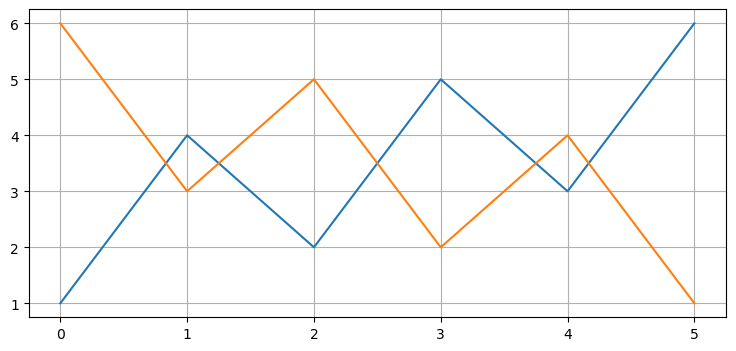

In [18]:
import matplotlib.pyplot as plt
a = np.array([6, 3, 5, 2, 4, 1])
plt.plot([1, 4, 2, 5, 3, 6])
plt.plot(a)

输出 `[<matplotlib.lines.Line2D at 0x2ba160bed68>]` 是因为 `plt.plot` 返回刚创建的对象。通常不想看到它，故在最后一次绘图命令后加 `;` 以抑制输出。

默认 `plot` 假定 x 序列步长为 1。可传入 x 与 y 自定义 x 序列。


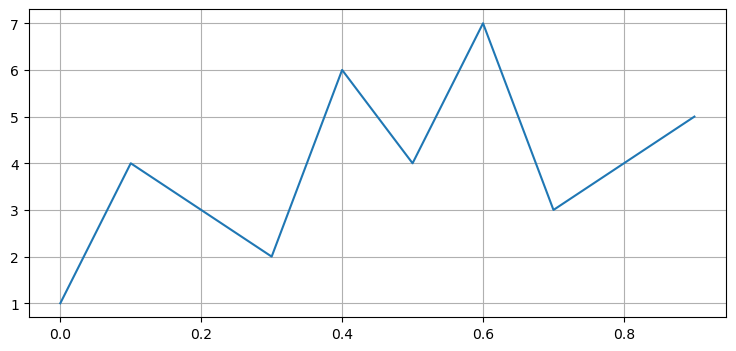

In [19]:
plt.plot(np.arange(0,1, 0.1), [1,4,3,2,6,4,7,3,4,5]);

这些包还有许多本书会用到的功能。通常我不加解释就引入，相信你从上下文能推断用法，或上网查说明。若不确定，在 Notebook 新建单元格或打开 Python 控制台试验即可！


### 练习——创建数组

请创建一个含 10 个元素的 NumPy 数组，每个元素为 1/10。做法有多种，请尽量多想几种实现。


In [20]:
# your solution

### 解答

下面三种做法。第一种是我希望你掌握的：用 `/` 运算符把数组每个元素除以 10。我们很快会用类似方式把数组单位从米换成千米。


In [21]:
print(np.ones(10) / 10.)
print(np.array([.1, .1, .1, .1, .1, .1, .1, .1, .1, .1]))
print(np.array([.1] * 10))

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


还有一种尚未介绍：`numpy.asarray()` 在参数还不是 ndarray 时将其转为 ndarray；若已是，数据不变。便于编写既接受 Python 列表又接受 ndarray 的函数；若已是 ndarray 则非常高效，因为不会新建对象。


In [22]:
def one_tenth(x):
    x = np.asarray(x)
    return x / 10.

print(one_tenth([1, 2, 3]))            # I work!
print(one_tenth(np.array([4, 5, 6])))  # so do I!

[0.1 0.2 0.3]
[0.4 0.5 0.6]


## 配套软件


我正在编写名为 FilterPy 的开源贝叶斯滤波（Bayesian filtering）Python 库，安装说明见上文。

FilterPy 托管在 GitHub（https://github.com/rlabbe/filterpy），但 `pip` 安装的版本应能满足需求。

与本书相关的代码存放在子目录 **/kf_book** 中，含格式化本书的代码，以及名为 *xxx*_internal.py 的 Python 文件，用于存放特定章节有用的函数，从而隐藏读起来不太有趣的 Python 代码——我可能在生成图或表，希望你关注图的内容而非我用 Python 生成图的机制。若好奇机制，可直接浏览源码。

部分章节会引入全书其余部分有用的函数：先在 Notebook 内定义，代码也存于 **/kf_book** 的 Python 文件中，供后续章节按需导入。我会在函数首次定义处说明，但仍在完善。我尽量避开这种做法，因为目录中的代码容易与书中不同步；但 Jupyter Notebook 无法引用其他 notebook 的代码单元格，这是我所知在 notebook 间共享功能的唯一办法。

还有一个未文档化的目录 **/experiments**，我在把代码写入书之前在此编写与测试。里面有些有趣内容，欢迎查看。随着本书演进，我会做示例与项目，不少材料会放到那里；小实验最终可能删除。若只想读书，可安全忽略该目录。


目录 **/kf_book** 含本书样式指南的 css 文件。Jupyter Notebook 默认外观较朴素。我借鉴了诸如 [Probabilistic Programming and Bayesian Methods for Hackers](http://nbviewer.ipython.org/github/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/blob/master/Chapter1_Introduction/Chapter1.ipynb) [2] 等书的范例，也深受 Lorena Barba 教授精彩作品 [点此](https://github.com/barbagroup/CFDPython) [3] 的影响。外观风格多归功于这些项目。


## 关于 Python 与数学编码的思考


多数卡尔曼滤波及其他工程教材由数学家或学者撰写，附带软件时（很少）也往往达不到生产质量。以 Paul Zarchan 的 *Fundamentals of Kalman Filtering* 为例：这是应入藏的好书，也是少数为每个示例与图表提供完整源码的书之一；但代码是 Fortran，除调用 `MATMUL` 等函数外几乎没有子程序。卡尔曼滤波在全书反复重新实现，同一清单里仿真与滤波代码混在一起，难以区分。有些章节以细微不同方式实现同一滤波器，用粗体标出少数改动行。若需要龙格-库塔（Runge Kutta），就嵌在代码里且无注释。

有更好的做法。若要做龙格-库塔，我调用 `ode45`，不在代码里嵌一套实现。我不想多次实现、多次调试龙格-库塔；若发现 bug，修一次即可确信所有项目都受益，而且可读。我很少关心龙格-库塔的实现细节。

本书讲卡尔曼滤波，可以说我们*确实*关心滤波器的实现——没错，但执行滤波的代码大约十来行，实现数学的代码相当琐碎。卡尔曼滤波的大部分工作在于设计送入数学引擎的矩阵。

一种可能的缺点是，执行滤波的方程藏在函数后面，有人会觉得在教学文本中是损失。我的看法相反：我希望你学会在真实项目、真实世界里使用卡尔曼滤波，而不应在各处剪切粘贴成熟算法。

我使用 Python 类，多半是把滤波器所需的数据组织起来，而非为了继承等面向对象（OO）特性。例如 `KalmanFilter` 类存放名为 `x`、`P`、`R`、`Q`、`S`、`y`、`K` 的矩阵与向量。我见过过程式的卡尔曼滤波库，要求程序员维护所有这些矩阵；玩具程序或许尚可，若要写一组卡尔曼滤波器，管理这些矩阵与相关数据就不会愉快。我在自己的工作中偶尔从这些类派生，觉得方便，但不想强推 OO，因为我知道许多人不喜欢。


## 许可


<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="http://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" property="dct:title">Kalman Filters and Random Signals in Python</span> by <a xmlns:cc="http://creativecommons.org/ns#" href="https://github.com/rlabbe/Kalman-Filters-and-Random-Signals-in-Python" property="cc:attributionName" rel="cc:attributionURL">Roger Labbe</a> is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License</a>.<br />

http://creativecommons.org/licenses/by-nc-sa/4.0/

Based on the work at <a xmlns:dct="http://purl.org/dc/terms/" href="https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python" rel="dct:source">https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python</a>.


## 联系方式


rlabbejr@gmail.com


## 资源


* [1] http://www.greenteapress.com/
* [2] http://nbviewer.ipython.org/github/CamDavidsonPilon/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/blob/master/Chapter1_Introduction/Chapter1.ipynb
* [3] https://github.com/barbagroup/CFDPython
